#  Mask-Guided Regularisation (RQ4)

This notebook asks the follow-up: **can training the model to attend to the tumour actually fix that — or does it only make the heatmap *look* better?**

### The design, and why it is built this way
MGR adds a loss term pushing the model's attention map toward the expert mask. The obvious success metric (localisation improves) is **circular** — we optimised for it. So MGR is only credible if it passes tests it was *not* trained on:

| Guard | Purpose |
|---|---|
| **Mask-free faithfulness** (deletion/insertion) | MGR does not optimise these. Improvement here is real. |
| **Held-out patients** | Localisation measured only on patients never seen in training. |
| **Random-mask control** | Identical run with *shuffled* masks. If that "improves" things too, the effect is an artefact. |
| **Accuracy cost reported** | MGR usually costs accuracy. That trade-off is the finding, not a failure. |

### Three variants trained
1. **baseline** — plain cross-entropy
2. **mgr** — cross-entropy + λ · mask loss (true masks)
3. **mgr_random** — cross-entropy + λ · mask loss (**shuffled** masks) ← the control

### Technical note
Rather than differentiating through Grad-CAM (needs gradients-of-gradients; unstable to train), we supervise the **class-activation map formed from the final conv features and classifier weights** — a differentiable CAM surrogate that is standard in explanation-guided training and much more stable. This choice is stated in the Methodology.


In [15]:
# Cell 1 — install + imports
!pip install grad-cam==1.5.4 timm --quiet

from pathlib import Path
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F, timm
from torch.utils.data import DataLoader, Dataset
from scipy.ndimage import gaussian_filter
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cpu":
    print("WARNING: no GPU — this notebook will be very slow.")

device: cuda


## Cell 2 — settings

`LAMBDA` is the mask-loss weight. 1.0 with normalised losses is a sensible start; tune here if the accuracy cost is too high (lower it) or localisation barely moves (raise it).

In [16]:
# Cell 2 
IN_DIR  = "/kaggle/input"
OUT_DIR = "/kaggle/working/mgr"

ARCH    = "resnet18"
LAMBDA  = 1.0                 # mask-loss weight 
VARIANTS = ["baseline", "mgr", "mgr_random"]
FOLDS   = [0, 1, 2, 3, 4]
SEED    = 42
EPOCHS  = 20
BATCH   = 32
LR      = 3e-4
N_FAITH = 40                  # images per fold for the faithfulness check

In [17]:
# Cell 3 — locate inputs
def find(name):
    hits = list(Path(IN_DIR).rglob(name))
    assert hits, f"{name} not found under {IN_DIR}."
    return hits[0]

images   = np.load(find("images.npy"))
masks    = np.load(find("masks.npy"))
manifest = pd.read_csv(find("manifest_splits.csv"))
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
print("images", images.shape, "| masks", masks.shape)

images (3064, 224, 224) | masks (3064, 224, 224)


## Cell 4 — dataset (returns the mask too)

For `mgr_random`, masks are shuffled **across images once, deterministically**, so each image is paired with a different image's mask. Same loss, same magnitude, no true spatial information — exactly what a control needs.

In [18]:
# Cell 4 — dataset
IMAGENET_MEAN = np.array([0.485,0.456,0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229,0.224,0.225], dtype=np.float32)

class MaskDS(Dataset):
    def __init__(self, imgs, msks, labels, train=False):
        self.imgs, self.msks, self.labels, self.train = imgs, msks, labels, train
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        img = self.imgs[i].astype(np.float32)/255.0
        msk = self.msks[i].astype(np.float32)
        if self.train and np.random.rand() < 0.5:
            img = np.fliplr(img).copy(); msk = np.fliplr(msk).copy()   # flip BOTH
        img = np.stack([img]*3,-1); img = (img-IMAGENET_MEAN)/IMAGENET_STD
        return (torch.from_numpy(img.transpose(2,0,1)),
                torch.from_numpy(msk[None,...]),
                int(self.labels[i]))

def set_seed(s):
    np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

def shuffled_masks(masks, seed=0):
    """Pair each image with another image's mask — the control."""
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(masks))
    # ensure no image keeps its own mask
    fixed = np.where(perm == np.arange(len(masks)))[0]
    if len(fixed) > 0:
        perm[fixed] = perm[(fixed + 1) % len(perm)]
    return masks[perm]

print("dataset ready")

dataset ready


## Cell 5 — the differentiable CAM and the mask loss

`cam_from_features` builds a class activation map from the final conv features weighted by the classifier weights for the predicted-target class — fully differentiable, so the mask term trains.

The mask loss is a **soft Dice** between the normalised CAM and the mask (upsampled to the CAM's resolution). Dice handles the severe foreground/background imbalance (tumours are ~2% of the image) far better than pixelwise MSE, which would be dominated by background.

In [19]:
# Cell 5 — CAM + loss
def cam_from_features(feats, fc_weight, targets):
    """feats: (B,C,h,w)  fc_weight: (num_classes,C)  targets: (B,)"""
    w = fc_weight[targets]                    # (B,C)
    cam = (feats * w[:, :, None, None]).sum(1, keepdim=True)   # (B,1,h,w)
    cam = F.relu(cam)
    B = cam.shape[0]
    flat = cam.view(B, -1)
    mx = flat.max(1)[0].view(B,1,1,1) + 1e-8
    return cam / mx                           # normalised to [0,1]

def mask_loss_fn(cam, mask):
    """Soft Dice between CAM and mask, computed at CAM resolution."""
    m = F.interpolate(mask, size=cam.shape[-2:], mode="area")
    m = (m > 0.5).float()
    num = 2*(cam*m).sum((1,2,3)) + 1e-6
    den = cam.sum((1,2,3)) + m.sum((1,2,3)) + 1e-6
    return (1 - num/den).mean()

print("loss ready")

loss ready


## Cell 6 — training one variant

Hooks the final conv block to grab features, computes the CAM for the **true** class during training, and adds λ·Dice to cross-entropy. `baseline` skips the mask term entirely.

In [20]:
# Cell 6 — train
def train_variant(variant, fold):
    out = Path(OUT_DIR)/f"model_{variant}_fold{fold}.pt"
    if out.exists():
        print(f"  {variant} fold {fold}: exists, skipping"); return
    set_seed(SEED)
    labels = manifest["label"].values - 1
    use_masks = masks if variant != "mgr_random" else shuffled_masks(masks, seed=0)

    tr = np.where((manifest.fold_honest != fold).values)[0]
    te = np.where((manifest.fold_honest == fold).values)[0]
    g = torch.Generator(); g.manual_seed(SEED)
    tr_dl = DataLoader(MaskDS(images[tr], use_masks[tr], labels[tr], True),
                       batch_size=BATCH, shuffle=True, num_workers=2, generator=g)
    te_dl = DataLoader(MaskDS(images[te], use_masks[te], labels[te], False), batch_size=BATCH)

    model = timm.create_model(ARCH, pretrained=True, num_classes=3).to(device)
    feats_store = {}
    model.layer4.register_forward_hook(lambda m,i,o: feats_store.update(f=o))

    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    ce = nn.CrossEntropyLoss()

    for ep in range(EPOCHS):
        model.train()
        for x, m, y in tr_dl:
            x, m, y = x.to(device), m.to(device), y.to(device)
            logits = model(x)
            loss = ce(logits, y)
            if variant != "baseline":
                cam = cam_from_features(feats_store["f"], model.fc.weight, y)
                loss = loss + LAMBDA * mask_loss_fn(cam, m)
            opt.zero_grad(); loss.backward(); opt.step()
        sch.step()

    model.eval(); correct = tot = 0
    with torch.no_grad():
        for x, m, y in te_dl:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item(); tot += len(y)
    torch.save(model.state_dict(), out)
    print(f"  {variant} fold {fold}: acc {correct/tot:.4f}")
    return correct/tot

print("trainer ready")

trainer ready


## Cell 7 — run all variants

15 runs. Progress prints per model.

In [8]:
# Cell 7 — train everything
for variant in VARIANTS:
    print(f"=== {variant} ===")
    for fold in FOLDS:
        train_variant(variant, fold)
print("all training done")

=== baseline ===


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

  baseline fold 0: acc 0.9566
  baseline fold 1: acc 0.8899
  baseline fold 2: acc 0.9801
  baseline fold 3: acc 0.9139
  baseline fold 4: acc 0.9379
=== mgr ===
  mgr fold 0: acc 0.9783
  mgr fold 1: acc 0.8862
  mgr fold 2: acc 0.9801
  mgr fold 3: acc 0.9401
  mgr fold 4: acc 0.9597
=== mgr_random ===
  mgr_random fold 0: acc 0.9581
  mgr_random fold 1: acc 0.8713
  mgr_random fold 2: acc 0.9734
  mgr_random fold 3: acc 0.9095
  mgr_random fold 4: acc 0.9379
all training done


## Cell 8 — evaluate: localisation, accuracy, and mask-free faithfulness

All three variants scored on the **held-out** fold. Localisation via Grad-CAM vs the true mask; faithfulness via deletion/insertion (mask-free — the honest test).

In [9]:
# Cell 8 — evaluation
import sys
from pathlib import Path
import numpy as np, pandas as pd, torch
from scipy.ndimage import gaussian_filter
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def log(*a):
    print(*a, flush=True); sys.stdout.flush()

log("Cell 8 starting...")

# --- check models exist before the slow part ---
missing = [f"model_{v}_fold{f}.pt" for v in VARIANTS for f in FOLDS
           if not (Path(OUT_DIR)/f"model_{v}_fold{f}.pt").exists()]
if missing:
    log(f"MISSING {len(missing)} models — Cell 7 did not finish:")
    for m in missing[:10]:
        log("  ", m)
    raise SystemExit("Re-run Cell 7 before Cell 8.")
log(f"All {len(VARIANTS)*len(FOLDS)} models present.")

IMAGENET_MEAN = np.array([0.485,0.456,0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229,0.224,0.225], dtype=np.float32)

def prep(img_uint8):
    a = np.stack([img_uint8.astype(np.float32)/255.0]*3,-1)
    a = (a-IMAGENET_MEAN)/IMAGENET_STD
    return torch.from_numpy(a.transpose(2,0,1).astype(np.float32))

def load(variant, fold):
    import timm
    m = timm.create_model(ARCH, pretrained=False, num_classes=3)
    m.load_state_dict(torch.load(Path(OUT_DIR)/f"model_{variant}_fold{fold}.pt",
                                 map_location=device))
    return m.to(device).eval()

def epg_scores(cam, mask):
    mb = mask.astype(bool); tot = cam.sum()
    epg = float(cam[mb].sum()/tot) if tot>0 else 0.0
    peak = np.unravel_index(np.argmax(cam), cam.shape)
    b = cam >= 0.5
    inter = np.logical_and(b, mb).sum(); union = np.logical_or(b, mb).sum()
    return epg, int(mb[peak]), float(inter/union) if union>0 else 0.0

def del_ins(model, img_uint8, attribution, steps=50):
    H,W = img_uint8.shape; raw = img_uint8.astype(np.float32)/255.0
    blur = gaussian_filter(raw, sigma=8)
    order = np.argsort(attribution.flatten())[::-1]; n=H*W; step=max(1,n//steps)
    with torch.no_grad():
        pred = int(model(prep(img_uint8).unsqueeze(0).to(device)).argmax(1).item())
    di, ii, fr = [], [], []
    for s in range(steps+1):
        k=s*step
        d=raw.flatten().copy(); d[order[:k]]=0.0
        ins=blur.flatten().copy(); ins[order[:k]]=raw.flatten()[order[:k]]
        di.append(prep((d.reshape(H,W)*255).astype(np.uint8)))
        ii.append(prep((ins.reshape(H,W)*255).astype(np.uint8))); fr.append(k/n)
    with torch.no_grad():
        dp=torch.softmax(model(torch.stack(di).to(device)),1)[:,pred].cpu().numpy()
        ip=torch.softmax(model(torch.stack(ii).to(device)),1)[:,pred].cpu().numpy()
    return float(np.trapz(dp,fr)), float(np.trapz(ip,fr))

rng = np.random.default_rng(0)
rows = []
labels = manifest["label"].values - 1

for variant in VARIANTS:
    for fold in FOLDS:
        model = load(variant, fold)
        eng = GradCAM(model=model, target_layers=[model.layer4[-1]])
        te = np.where((manifest.fold_honest==fold).values)[0]
        pick = set(rng.choice(te, min(N_FAITH, len(te)), replace=False).tolist())
        for i in te:
            x = prep(images[i]).unsqueeze(0).to(device)
            with torch.no_grad(): pred=int(model(x).argmax(1).item())
            cam = eng(input_tensor=x, targets=[ClassifierOutputTarget(pred)])[0]
            epg, pg, iou = epg_scores(cam, masks[i])
            r = {"variant":variant,"fold":fold,"idx":int(i),"pid":manifest.pid.values[i],
                 "correct":int(pred==labels[i]),"epg":epg,"pg":pg,"iou":iou,
                 "del_auc":np.nan,"ins_auc":np.nan}
            if int(i) in pick:
                d,ins = del_ins(model, images[i], cam)
                r["del_auc"], r["ins_auc"] = d, ins
            rows.append(r)
        del model, eng; torch.cuda.empty_cache()
        log(f"  {variant} fold {fold} done — {len(rows)} rows so far")
    # save partial after each variant
    pd.DataFrame(rows).to_csv(Path(OUT_DIR)/"mgr_eval.csv", index=False)
    log(f"{variant}: COMPLETE (partial results saved)")

ev = pd.DataFrame(rows)
ev.to_csv(Path(OUT_DIR)/"mgr_eval.csv", index=False)
log(f"FINISHED — saved mgr_eval.csv with {len(ev)} rows")


Cell 8 starting...
All 15 models present.


/tmp/ipykernel_58/3699942044.py:63: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(dp,fr)), float(np.trapz(ip,fr))


  baseline fold 0 done — 645 rows so far
  baseline fold 1 done — 1181 rows so far
  baseline fold 2 done — 1783 rows so far
  baseline fold 3 done — 2468 rows so far
  baseline fold 4 done — 3064 rows so far
baseline: COMPLETE (partial results saved)
  mgr fold 0 done — 3709 rows so far
  mgr fold 1 done — 4245 rows so far
  mgr fold 2 done — 4847 rows so far
  mgr fold 3 done — 5532 rows so far
  mgr fold 4 done — 6128 rows so far
mgr: COMPLETE (partial results saved)
  mgr_random fold 0 done — 6773 rows so far
  mgr_random fold 1 done — 7309 rows so far
  mgr_random fold 2 done — 7911 rows so far
  mgr_random fold 3 done — 8596 rows so far
  mgr_random fold 4 done — 9192 rows so far
mgr_random: COMPLETE (partial results saved)
FINISHED — saved mgr_eval.csv with 9192 rows


## Cell 9 — the result table

**Read it in this order:**
1. **mgr vs mgr_random on localisation.** If both improve equally, the effect is an artefact of the extra loss term, not the masks.
2. **mgr vs baseline on faithfulness (del/ins).** MGR did *not* optimise these. Improvement here is the real contribution.
3. **Accuracy cost.** Report it whatever it is.

In [10]:
# Cell 9 — summary
pat = ev.groupby(["variant","pid"])[["epg","iou","pg"]].mean().reset_index()
loc = pat.groupby("variant")[["epg","iou","pg"]].agg(["mean","std"]).round(4)
print("LOCALISATION (patient-level, held-out folds)")
print(loc.to_string())

print("\nFAITHFULNESS (mask-free — the honest test)")
fa = ev.dropna(subset=["del_auc"]).groupby("variant")[["del_auc","ins_auc"]].agg(["mean","std"]).round(4)
print(fa.to_string())
print("  del_auc: lower = more faithful | ins_auc: higher = more faithful")

print("\nACCURACY (held-out folds)")
acc = ev.groupby(["variant","fold"]).correct.mean().reset_index()
print(acc.groupby("variant").correct.agg(["mean","std"]).round(4).to_string())

print("\n--- VERDICT CHECKS ---")
b = pat[pat.variant=="baseline"].epg.mean()
m = pat[pat.variant=="mgr"].epg.mean()
r = pat[pat.variant=="mgr_random"].epg.mean()
print(f"EPG  baseline {b:.4f} | mgr {m:.4f} | mgr_random {r:.4f}")
print(f"  MGR gain over baseline : {m-b:+.4f}")
print(f"  Control gain over base : {r-b:+.4f}   <-- should be much smaller")
if r - b > 0.5*(m - b):
    print("  WARNING: control improved nearly as much — effect may be an artefact.")

LOCALISATION (patient-level, held-out folds)
               epg             iou              pg        
              mean     std    mean     std    mean     std
variant                                                   
baseline    0.0528  0.0431  0.0813  0.0677  0.1353  0.2084
mgr         0.2066  0.1666  0.2175  0.1359  0.4244  0.3177
mgr_random  0.0767  0.0641  0.0912  0.0814  0.1140  0.1809

FAITHFULNESS (mask-free — the honest test)
           del_auc         ins_auc        
              mean     std    mean     std
variant                                   
baseline    0.5101  0.1845  0.9299  0.0743
mgr         0.4970  0.1866  0.8437  0.1493
mgr_random  0.4438  0.1221  0.8940  0.1260
  del_auc: lower = more faithful | ins_auc: higher = more faithful

ACCURACY (held-out folds)
              mean     std
variant                   
baseline    0.9357  0.0353
mgr         0.9489  0.0386
mgr_random  0.9300  0.0407

--- VERDICT CHECKS ---
EPG  baseline 0.0528 | mgr 0.2066 | mgr_random

## Cell 10 — visual comparison (thesis figure)

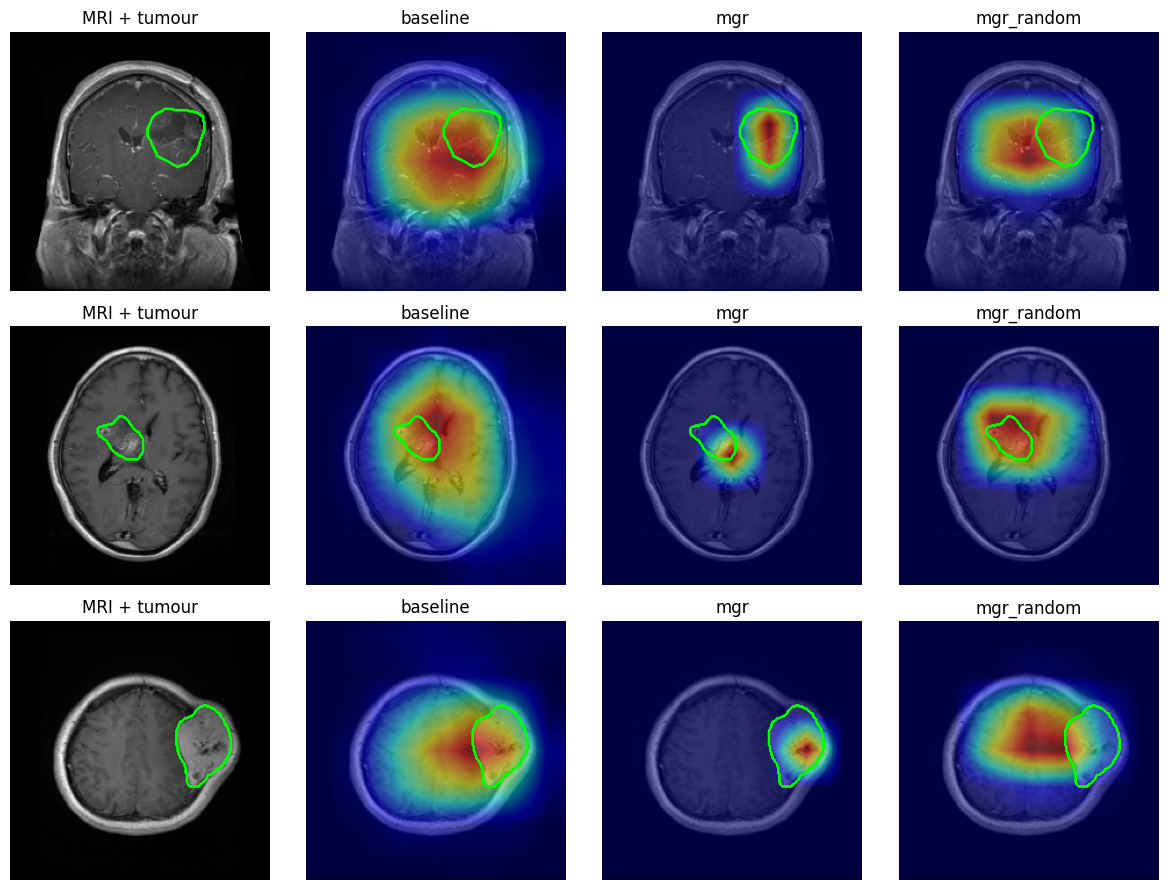

In [11]:
# Cell 10 — figure
import matplotlib.pyplot as plt
fold = 0
mods = {v: load(v, fold) for v in VARIANTS}
te = np.where((manifest.fold_honest==fold).values)[0]
show = np.random.default_rng(5).choice(te, 3, replace=False)

fig, axes = plt.subplots(len(show), 4, figsize=(12, 3*len(show)))
for r,i in enumerate(show):
    axes[r,0].imshow(images[i], cmap="gray"); axes[r,0].contour(masks[i], colors="lime", linewidths=1)
    axes[r,0].set_title("MRI + tumour"); axes[r,0].axis("off")
    for c,v in enumerate(VARIANTS):
        eng = GradCAM(model=mods[v], target_layers=[mods[v].layer4[-1]])
        x = prep(images[i]).unsqueeze(0).to(device)
        with torch.no_grad(): pred=int(mods[v](x).argmax(1).item())
        cam = eng(input_tensor=x, targets=[ClassifierOutputTarget(pred)])[0]
        axes[r,c+1].imshow(images[i], cmap="gray"); axes[r,c+1].imshow(cam, cmap="jet", alpha=.5)
        axes[r,c+1].contour(masks[i], colors="lime", linewidths=1)
        axes[r,c+1].set_title(v); axes[r,c+1].axis("off")
plt.tight_layout(); plt.savefig(Path(OUT_DIR)/"mgr_comparison.png", dpi=130); plt.show()

# ============================================================
# CELL A — seed-aware training
# ============================================================

In [21]:

import sys
from pathlib import Path
import numpy as np, pandas as pd, torch, torch.nn as nn, timm
from torch.utils.data import DataLoader

def log(*a): print(*a, flush=True)

EXTRA_SEEDS = [1, 2]          # seed 42 is already trained

def model_path(variant, fold, seed):
    if seed == 42:
        return Path(OUT_DIR)/f"model_{variant}_fold{fold}.pt"
    return Path(OUT_DIR)/f"model_{variant}_seed{seed}_fold{fold}.pt"

def train_variant_seeded(variant, fold, seed):
    out = model_path(variant, fold, seed)
    if out.exists():
        log(f"  {variant} seed{seed} fold{fold}: exists, skipping"); return
    set_seed(seed)
    labels = manifest["label"].values - 1
    use_masks = masks if variant != "mgr_random" else shuffled_masks(masks, seed=0)

    tr = np.where((manifest.fold_honest != fold).values)[0]
    te = np.where((manifest.fold_honest == fold).values)[0]
    g = torch.Generator(); g.manual_seed(seed)
    tr_dl = DataLoader(MaskDS(images[tr], use_masks[tr], labels[tr], True),
                       batch_size=BATCH, shuffle=True, num_workers=2, generator=g)
    te_dl = DataLoader(MaskDS(images[te], use_masks[te], labels[te], False), batch_size=BATCH)

    model = timm.create_model(ARCH, pretrained=True, num_classes=3).to(device)
    feats_store = {}
    model.layer4.register_forward_hook(lambda m,i,o: feats_store.update(f=o))
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    ce = nn.CrossEntropyLoss()

    for ep in range(EPOCHS):
        model.train()
        for x, m, y in tr_dl:
            x, m, y = x.to(device), m.to(device), y.to(device)
            logits = model(x); loss = ce(logits, y)
            if variant != "baseline":
                cam = cam_from_features(feats_store["f"], model.fc.weight, y)
                loss = loss + LAMBDA * mask_loss_fn(cam, m)
            opt.zero_grad(); loss.backward(); opt.step()
        sch.step()

    model.eval(); correct = tot = 0
    with torch.no_grad():
        for x, m, y in te_dl:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1)==y).sum().item(); tot += len(y)
    torch.save(model.state_dict(), out)
    del model; torch.cuda.empty_cache()
    log(f"  {variant} seed{seed} fold{fold}: acc {correct/tot:.4f}")



In [26]:
from pathlib import Path
for v in VARIANTS:
    for s in [42, 1, 2]:
        have = [f for f in FOLDS if model_path(v, f, s).exists()]
        print(f"{v:11s} seed{s}: folds {have}")

baseline    seed42: folds [0, 1, 2, 3, 4]
baseline    seed1: folds [0, 1, 2, 3, 4]
baseline    seed2: folds [0, 1, 2, 3, 4]
mgr         seed42: folds [0, 1, 2, 3, 4]
mgr         seed1: folds [0, 1, 2, 3, 4]
mgr         seed2: folds [0, 1, 2, 3, 4]
mgr_random  seed42: folds [0, 1, 2, 3, 4]
mgr_random  seed1: folds [0, 1, 2, 3, 4]
mgr_random  seed2: folds [0, 1, 2, 3, 4]


In [25]:
VARIANT_NOW = "mgr_random"      # then "mgr", then "mgr_random"

for seed in EXTRA_SEEDS:
    log(f"=== {VARIANT_NOW} seed {seed} ===")
    for fold in FOLDS:
        train_variant_seeded(VARIANT_NOW, fold, seed)
log("done — now change VARIANT_NOW and re-run this cell")

=== mgr_random seed 1 ===
  mgr_random seed1 fold0: exists, skipping
  mgr_random seed1 fold1: exists, skipping
  mgr_random seed1 fold2: exists, skipping
  mgr_random seed1 fold3: exists, skipping
  mgr_random seed1 fold4: exists, skipping
=== mgr_random seed 2 ===
  mgr_random seed2 fold0: exists, skipping
  mgr_random seed2 fold1: exists, skipping
  mgr_random seed2 fold2: exists, skipping
  mgr_random seed2 fold3: exists, skipping
  mgr_random seed2 fold4: exists, skipping
done — now change VARIANT_NOW and re-run this cell


# evaluate all seeds

In [27]:
ALL_SEEDS = [42] + EXTRA_SEEDS

def load_seeded(variant, fold, seed):
    m = timm.create_model(ARCH, pretrained=False, num_classes=3)
    m.load_state_dict(torch.load(model_path(variant, fold, seed), map_location=device))
    return m.to(device).eval()

missing = [(v,f,s) for v in VARIANTS for f in FOLDS for s in ALL_SEEDS
           if not model_path(v,f,s).exists()]
if missing:
    log(f"MISSING {len(missing)} models, e.g. {missing[:5]}")
    raise SystemExit("Finish training first.")
log(f"All {len(VARIANTS)*len(FOLDS)*len(ALL_SEEDS)} models present.")

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

rng = np.random.default_rng(0)
rows = []
labels = manifest["label"].values - 1
for variant in VARIANTS:
    for seed in ALL_SEEDS:
        for fold in FOLDS:
            model = load_seeded(variant, fold, seed)
            eng = GradCAM(model=model, target_layers=[model.layer4[-1]])
            te = np.where((manifest.fold_honest==fold).values)[0]
            pick = set(rng.choice(te, min(N_FAITH, len(te)), replace=False).tolist())
            for i in te:
                x = prep(images[i]).unsqueeze(0).to(device)
                with torch.no_grad(): pred=int(model(x).argmax(1).item())
                cam = eng(input_tensor=x, targets=[ClassifierOutputTarget(pred)])[0]
                epg, pg, iou = epg_scores(cam, masks[i])
                r = {"variant":variant,"seed":seed,"fold":fold,"idx":int(i),
                     "pid":manifest.pid.values[i],"correct":int(pred==labels[i]),
                     "epg":epg,"pg":pg,"iou":iou,"del_auc":np.nan,"ins_auc":np.nan}
                if int(i) in pick:
                    d,ins = del_ins(model, images[i], cam)
                    r["del_auc"], r["ins_auc"] = d, ins
                rows.append(r)
            del model, eng; torch.cuda.empty_cache()
            log(f"  {variant} seed{seed} fold{fold} done")
    pd.DataFrame(rows).to_csv(Path(OUT_DIR)/"mgr_eval_multiseed.csv", index=False)
    log(f"{variant}: COMPLETE")

evm = pd.DataFrame(rows)
evm.to_csv(Path(OUT_DIR)/"mgr_eval_multiseed.csv", index=False)
log(f"FINISHED — {len(evm)} rows")

All 45 models present.


/tmp/ipykernel_58/3699942044.py:63: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(dp,fr)), float(np.trapz(ip,fr))


  baseline seed42 fold0 done
  baseline seed42 fold1 done
  baseline seed42 fold2 done
  baseline seed42 fold3 done
  baseline seed42 fold4 done
  baseline seed1 fold0 done
  baseline seed1 fold1 done
  baseline seed1 fold2 done
  baseline seed1 fold3 done
  baseline seed1 fold4 done
  baseline seed2 fold0 done
  baseline seed2 fold1 done
  baseline seed2 fold2 done
  baseline seed2 fold3 done
  baseline seed2 fold4 done
baseline: COMPLETE
  mgr seed42 fold0 done
  mgr seed42 fold1 done
  mgr seed42 fold2 done
  mgr seed42 fold3 done
  mgr seed42 fold4 done
  mgr seed1 fold0 done
  mgr seed1 fold1 done
  mgr seed1 fold2 done
  mgr seed1 fold3 done
  mgr seed1 fold4 done
  mgr seed2 fold0 done
  mgr seed2 fold1 done
  mgr seed2 fold2 done
  mgr seed2 fold3 done
  mgr seed2 fold4 done
mgr: COMPLETE
  mgr_random seed42 fold0 done
  mgr_random seed42 fold1 done
  mgr_random seed42 fold2 done
  mgr_random seed42 fold3 done
  mgr_random seed42 fold4 done
  mgr_random seed1 fold0 done
  mgr_r

# multi-seed summary

In [28]:
print("PER-SEED RESULTS (is the pattern consistent?)")
print("="*66)
for seed in ALL_SEEDS:
    s = evm[evm.seed==seed]
    pat = s.groupby(["variant","pid"]).epg.mean().reset_index()
    fa  = s.dropna(subset=["ins_auc"]).groupby("variant")[["del_auc","ins_auc"]].mean()
    print(f"\nseed {seed}")
    for v in VARIANTS:
        e = pat[pat.variant==v].epg.mean()
        print(f"  {v:11s} EPG {e:.4f} | del {fa.loc[v,'del_auc']:.4f} "
              f"| ins {fa.loc[v,'ins_auc']:.4f}")

print("\n\nPOOLED ACROSS SEEDS (report these)")
print("="*66)
pat = evm.groupby(["variant","seed","pid"])[["epg","iou","pg"]].mean().reset_index()
print("\nLOCALISATION")
print(pat.groupby("variant")[["epg","iou","pg"]].agg(["mean","std"]).round(4).to_string())
print("\nFAITHFULNESS (mask-free)")
print(evm.dropna(subset=["ins_auc"]).groupby("variant")[["del_auc","ins_auc"]]
        .agg(["mean","std"]).round(4).to_string())
print("\nACCURACY")
acc = evm.groupby(["variant","seed","fold"]).correct.mean().reset_index()
print(acc.groupby("variant").correct.agg(["mean","std"]).round(4).to_string())

print("\n\nKEY CHECKS")
print("="*66)
b_e = pat[pat.variant=="baseline"].epg.mean()
m_e = pat[pat.variant=="mgr"].epg.mean()
r_e = pat[pat.variant=="mgr_random"].epg.mean()
print(f"EPG gain  MGR {m_e-b_e:+.4f}  vs control {r_e-b_e:+.4f}")
fa = evm.dropna(subset=["ins_auc"]).groupby("variant")[["del_auc","ins_auc"]].mean()
print(f"Insertion baseline {fa.loc['baseline','ins_auc']:.4f} -> "
      f"MGR {fa.loc['mgr','ins_auc']:.4f} "
      f"({fa.loc['mgr','ins_auc']-fa.loc['baseline','ins_auc']:+.4f})")
print("\nIf the insertion drop appears in ALL seeds, the cosmetic-alignment")
print("finding is solid. If it appears in only one, report it as tentative.")


PER-SEED RESULTS (is the pattern consistent?)

seed 42
  baseline    EPG 0.0528 | del 0.5101 | ins 0.9299
  mgr         EPG 0.2066 | del 0.5167 | ins 0.8668
  mgr_random  EPG 0.0767 | del 0.4487 | ins 0.9081

seed 1
  baseline    EPG 0.0511 | del 0.4716 | ins 0.8996
  mgr         EPG 0.1922 | del 0.5260 | ins 0.8453
  mgr_random  EPG 0.0771 | del 0.4585 | ins 0.8885

seed 2
  baseline    EPG 0.0502 | del 0.5252 | ins 0.9142
  mgr         EPG 0.2183 | del 0.5323 | ins 0.8272
  mgr_random  EPG 0.0767 | del 0.4929 | ins 0.8972


POOLED ACROSS SEEDS (report these)

LOCALISATION
               epg             iou              pg        
              mean     std    mean     std    mean     std
variant                                                   
baseline    0.0514  0.0427  0.0810  0.0716  0.1432  0.2189
mgr         0.2057  0.1667  0.2173  0.1351  0.4251  0.3224
mgr_random  0.0768  0.0647  0.0920  0.0830  0.1224  0.1856

FAITHFULNESS (mask-free)
           del_auc         ins_auc     

In [29]:
from pathlib import Path
import shutil
from IPython.display import FileLink

for f in sorted(Path("/kaggle/working").rglob("*.csv")):
    print(f, f"({f.stat().st_size/1024:.0f} KB)")

# copy the multiseed file to the working root where it's easy to find
src = Path(OUT_DIR)/"mgr_eval_multiseed.csv"
if src.exists():
    shutil.copy(src, "/kaggle/working/mgr_eval_multiseed.csv")
    display(FileLink("/kaggle/working/mgr_eval_multiseed.csv"))
else:
    print("not on disk — re-saving from memory")
    evm.to_csv("/kaggle/working/mgr_eval_multiseed.csv", index=False)
    display(FileLink("/kaggle/working/mgr_eval_multiseed.csv"))

/kaggle/working/mgr/mgr_eval.csv (613 KB)
/kaggle/working/mgr/mgr_eval_multiseed.csv (1897 KB)


/kaggle/working/mgr_eval_multiseed.csv